In [2]:
"""
Block 1: Configuration (Extension 1b Baseline)
Defines training setup, output directory, and augmentation toggles.
"""
import os

# --- 1. Execution Mode ---
TEST_MODE = False  

# --- 2. Dataset & Model ---
DATA_SET = "CIFAR"
DATA_PATH = "./data/cifar100"
NB_CLASSES = 100
INPUT_SIZE = 32
MODEL_NAME = "convnext_tiny"

# --- 3. Hyperparameters ---
BATCH_SIZE = 128
EPOCHS = 100
WARMUP_EPOCHS = 20
OPT = "adamw"
LR = 4e-3
WEIGHT_DECAY = 0.05
DROP_PATH = 0.1

# --- 4. Augmentation Control Panel ---
MIXUP = 0.0
CUTMIX = 0.0
SMOOTHING = 0.0
COLOR_JITTER = 0.0 
REPROB = 0.0       
AA_POLICY = ""  

# Extension 1b: Manual Affine Parameters ---
ROTATION = 15      
TRANSLATION = 0.1  
SHEAR = 10

# --- 5. Model EMA ---
MODEL_EMA = "false"
MODEL_EMA_EVAL = "false"

# --- 6. Output ---
CHECKPOINT_DIR = "./output/ext1b_randomaffine"
REPO_NAME = "dsa5106-convnext-extension"

In [3]:
"""
Block 2: Hardware Check
Verify PyTorch and GPU availability.
"""

import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
"""
Block 3: Clone ConvNeXt + compatibility patches + clean build_transform override for 1b
"""

import os
import shutil
import fileinput

os.chdir("/kaggle/working")

repo_name = "ConvNeXt"

if os.path.exists(repo_name):
    shutil.rmtree(repo_name)

!git clone https://github.com/facebookresearch/ConvNeXt.git -q
os.chdir(repo_name)

print("Working directory:", os.getcwd())

!pip install -q uv
!uv pip install --system timm==0.6.13 tensorboardX six


# Patch NovoGrad dependency
optim_file = "optim_factory.py"
if os.path.exists(optim_file):
    for line in fileinput.input(optim_file, inplace=True):
        if "from timm.optim.novograd import NovoGrad" in line:
            print("# " + line, end="")
        elif "NovoGrad(" in line:
            print(line.replace("NovoGrad(", "torch.optim.AdamW("), end="")
        else:
            print(line, end="")


# Patch deprecated torch._six import
utils_file = "utils.py"
if os.path.exists(utils_file):
    for line in fileinput.input(utils_file, inplace=True):
        if "from torch._six import inf" in line:
            print("from math import inf")
        else:
            print(line, end="")


# Patch pretrained_cfg wrapper
convnext_file = "models/convnext.py"
if os.path.exists(convnext_file):
    with open(convnext_file, "r") as f:
        lines = f.readlines()

    updated_lines = []
    for line in lines:
        updated_lines.append(line)
        if line.strip().startswith("def convnext_tiny("):
            updated_lines.append("    kwargs.pop('pretrained_cfg', None)\n")

    with open(convnext_file, "w") as f:
        f.writelines(updated_lines)


# Override build_transform cleanly
datasets_file = "datasets.py"

with open(datasets_file, "r") as f:
    content = f.read()

override_block = f"""
def build_transform(is_train, args):
    if args.data_set == 'CIFAR':
        from torchvision import transforms

        if is_train:
            return transforms.Compose([
                transforms.RandomCrop(32, padding=4),
                transforms.RandomHorizontalFlip(),
                transforms.RandomAffine(
                    degrees={ROTATION},
                    translate=({TRANSLATION}, {TRANSLATION}),
                    shear={SHEAR}
                ),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=(0.5071, 0.4867, 0.4408),
                    std=(0.2675, 0.2565, 0.2761)
                ),
            ])
        else:
            return transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=(0.5071, 0.4867, 0.4408),
                    std=(0.2675, 0.2565, 0.2761)
                ),
            ])
"""

start = content.find("def build_transform(")
end = content.find("def build_dataset", start)

new_content = content[:start] + override_block + content[end:]

with open(datasets_file, "w") as f:
    f.write(new_content)

print("build_transform successfully overridden for CIFAR.")

Working directory: /kaggle/working/ConvNeXt
Using Python 3.12.12 environment at: /usr
Audited 3 packages in 126ms
build_transform successfully overridden for CIFAR.


In [5]:
"""
Block 3a: Verify runtime transform
"""

import sys
import importlib

if "/kaggle/working/ConvNeXt" not in sys.path:
    sys.path.insert(0, "/kaggle/working/ConvNeXt")

import datasets
importlib.reload(datasets)

class SimpleArgs:
    def __init__(self):
        self.data_set = 'CIFAR'
        self.data_path = DATA_PATH
        self.input_size = 32
        self.nb_classes = 100
        self.imagenet_default_mean_and_std = True
        self.color_jitter = 0.0
        self.aa = ""
        self.train_interpolation = 'bicubic'
        self.reprob = 0.0
        self.remode = 'pixel'
        self.recount = 1
        self.crop_pct = None

dataset_train, _ = datasets.build_dataset(is_train=True, args=SimpleArgs())

print("Runtime transform:\n")
for i, t in enumerate(dataset_train.transform.transforms):
    print(f"Index {i}: {t}")

Transform = 
RandomCrop(size=(32, 32), padding=4)
RandomHorizontalFlip(p=0.5)
RandomAffine(degrees=[-15.0, 15.0], translate=(0.1, 0.1), shear=[-10.0, 10.0])
ToTensor()
Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))
---------------------------


100%|██████████| 169M/169M [00:02<00:00, 70.4MB/s] 
/usr/local/lib/python3.12/dist-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Number of the class = 100
Runtime transform:

Index 0: RandomCrop(size=(32, 32), padding=4)
Index 1: RandomHorizontalFlip(p=0.5)
Index 2: RandomAffine(degrees=[-15.0, 15.0], translate=(0.1, 0.1), shear=[-10.0, 10.0])
Index 3: ToTensor()
Index 4: Normalize(mean=(0.5071, 0.4867, 0.4408), std=(0.2675, 0.2565, 0.2761))


In [6]:
"""
Block 4: Training Execution
"""

cmd = f"""
python main.py \
  --model {MODEL_NAME} \
  --data_set {DATA_SET} \
  --data_path {DATA_PATH} \
  --nb_classes {NB_CLASSES} \
  --input_size {INPUT_SIZE} \
  --batch_size {BATCH_SIZE} \
  --epochs {EPOCHS} \
  --warmup_epochs {WARMUP_EPOCHS} \
  --opt {OPT} \
  --lr {LR} \
  --weight_decay {WEIGHT_DECAY} \
  --drop_path {DROP_PATH} \
  --mixup {MIXUP} \
  --cutmix {CUTMIX} \
  --smoothing {SMOOTHING} \
  --color_jitter {COLOR_JITTER} \
  --aa "{AA_POLICY}" \
  --reprob {REPROB} \
  --model_ema {MODEL_EMA} \
  --model_ema_eval {MODEL_EMA_EVAL} \
  --output_dir {CHECKPOINT_DIR}
"""

print("Launching Training with Clean Baseline Config:")
print(cmd)
!{cmd}

Launching Training with Clean Baseline Config:

python main.py   --model convnext_tiny   --data_set CIFAR   --data_path ./data/cifar100   --nb_classes 100   --input_size 32   --batch_size 128   --epochs 100   --warmup_epochs 20   --opt adamw   --lr 0.004   --weight_decay 0.05   --drop_path 0.1   --mixup 0.0   --cutmix 0.0   --smoothing 0.0   --color_jitter 0.0   --aa ""   --reprob 0.0   --model_ema false   --model_ema_eval false   --output_dir ./output/ext1b_randomaffine

Not using distributed mode
Namespace(batch_size=128, epochs=100, update_freq=1, model='convnext_tiny', drop_path=0.1, input_size=32, layer_scale_init_value=1e-06, model_ema=False, model_ema_decay=0.9999, model_ema_force_cpu=False, model_ema_eval=False, opt='adamw', opt_eps=1e-08, opt_betas=None, clip_grad=None, momentum=0.9, weight_decay=0.05, weight_decay_end=None, lr=0.004, layer_decay=1.0, min_lr=1e-06, warmup_epochs=20, warmup_steps=-1, color_jitter=0.0, aa='', smoothing=0.0, train_interpolation='bicubic', crop_pc

In [7]:
"""
Block 5: Save Selected Checkpoints (97, 98, 99, Best)
"""

import os
import shutil

root_dir = "/kaggle/working"
archive_name = "ext1b_selected"

selected_files = [
    "checkpoint-97.pth",
    "checkpoint-98.pth",
    "checkpoint-99.pth",
    "checkpoint-best.pth",
    "log.txt",
]

temp_dir = os.path.join(root_dir, "extension_1a")
os.makedirs(temp_dir, exist_ok=True)

for file in selected_files:
    src = os.path.join(CHECKPOINT_DIR, file)
    if os.path.exists(src):
        shutil.copy(src, temp_dir)
        print("Added:", file)
    else:
        print("Missing:", file)

shutil.make_archive(
    os.path.join(root_dir, archive_name),
    "zip",
    temp_dir
)

print("Saved:", os.path.join(root_dir, archive_name + ".zip"))

Added: checkpoint-97.pth
Added: checkpoint-98.pth
Added: checkpoint-99.pth
Added: checkpoint-best.pth
Added: log.txt
Saved: /kaggle/working/ext1b_selected.zip


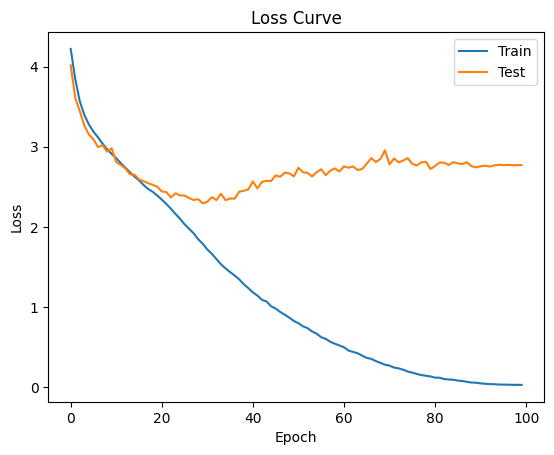

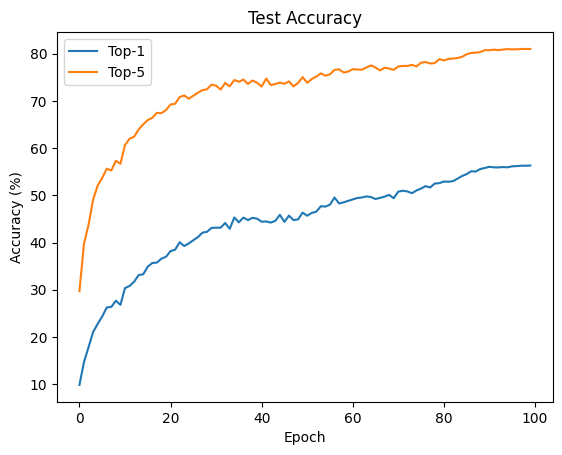

In [8]:
"""
Block 6: Visualize Training Metrics
Parse log.txt and plot loss + accuracy curves.
"""

import os
import json
import matplotlib.pyplot as plt

log_file = os.path.join(CHECKPOINT_DIR, "log.txt")

epochs = []
train_loss = []
test_loss = []
test_top1 = []
test_top5 = []

with open(log_file, "r") as f:
    for line in f:
        data = json.loads(line)
        epochs.append(data["epoch"])
        train_loss.append(data["train_loss"])
        test_loss.append(data["test_loss"])
        test_top1.append(data["test_acc1"])
        test_top5.append(data["test_acc5"])

# Plot Loss
plt.figure()
plt.plot(epochs, train_loss)
plt.plot(epochs, test_loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.title("Loss Curve")
plt.show()

# Plot Accuracy
plt.figure()
plt.plot(epochs, test_top1)
plt.plot(epochs, test_top5)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend(["Top-1", "Top-5"])
plt.title("Test Accuracy")
plt.show()